In [1]:
import os
import sys
import time
import glob
import numpy as np
import torch
import torch.nn.functional as F

from torch.utils.data import DataLoader, random_split, ConcatDataset
from tqdm import tqdm

# Paths
DATAROOT = "/scratch/users/joshua04/ECHO"
PROJECT_ROOT = "/scratch/users/joshua04/Echo-Code"

if PROJECT_ROOT not in sys.path:
    sys.path.insert(0, PROJECT_ROOT)

# Project modules
from src.datasets.cardiac_uda import CardiacUDADataset, PLOSONEDataset
from src.models.unet import UNet
from src.losses.metrics import (
    dice_score,
    per_class_dice,
    CombinedLoss,
    DeepSupervisionLoss,)

In [2]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

print("Device:", device)

if torch.cuda.is_available():
    print("GPU:", torch.cuda.get_device_name(0))
    props = torch.cuda.get_device_properties(0)
    vram = props.total_memory
    print(f"VRAM: {vram/1e9:.1f} GB")

DATA_ROOT = os.path.join(DATAROOT, "data", "cardiacUDC_dataset")
PLOSONE_ROOT = "/scratch/users/joshua04/ECHO/data/PLOSONE"
CKPT_DIR = os.path.join(PROJECT_ROOT, "checkpoints")
os.makedirs(CKPT_DIR, exist_ok=True)

NUM_CLASSES = 5
CLASS_NAMES = ["BG", "LV", "RV", "MYO", "ATR"]

BASE_CH = 64
IMG_SIZE = 384

BATCH_SIZE = 2
NUM_EPOCHS = 30

LR = 3e-4
WEIGHT_DECAY = 1e-4

CLASS_WEIGHTS = [0.15, 1.0, 1.0, 1.0, 1.0]

print("Dataset root:", DATA_ROOT)

Device: cuda
GPU: NVIDIA L40S
VRAM: 47.7 GB
Dataset root: /scratch/users/joshua04/ECHO/data/cardiacUDC_dataset


In [3]:
print("\nDiscovering dataset...")

for item in sorted(os.listdir(DATA_ROOT)):
    full = os.path.join(DATA_ROOT, item)
    if os.path.isdir(full):
        n = len(glob.glob(os.path.join(full, "*_image.nii.gz")))
        if n > 0:
            print(f"{item} -- {n} volumes")

# CardiacUDA source (G)
src_aug = CardiacUDADataset(DATA_ROOT, domain="G", resize=IMG_SIZE,
                            augment=True, normalize_mode="zscore")

src_clean = CardiacUDADataset(DATA_ROOT, domain="G", resize=IMG_SIZE,
                              augment=False, normalize_mode="zscore")

# CAMUS (partial labels)
camus_aug = CardiacUDADataset(DATA_ROOT, domain="CAMUS", resize=IMG_SIZE,
                              augment=True, normalize_mode="zscore")

camus_clean = CardiacUDADataset(DATA_ROOT, domain="CAMUS", resize=IMG_SIZE,
                                augment=False, normalize_mode="zscore")
plosone_aug = PLOSONEDataset(
    PLOSONE_ROOT, resize=IMG_SIZE, augment=True,
)

# Combine datasets
full_aug = ConcatDataset([src_aug, camus_aug])
full_clean = ConcatDataset([src_clean, camus_clean])

train_size = int(0.8 * len(full_aug))
val_size = len(full_aug) - train_size

train_ds, _ = random_split(full_aug, [train_size, val_size],
                           generator=torch.Generator().manual_seed(42))

_, val_ds = random_split(full_clean, [train_size, val_size],
                         generator=torch.Generator().manual_seed(42))

# Target domain (R)
tgt_ds = CardiacUDADataset(DATA_ROOT, domain="R", resize=IMG_SIZE,
                           augment=False, normalize_mode="zscore")

print("Train:", len(train_ds))
print("Val:", len(val_ds))
print("Target:", len(tgt_ds))


Discovering dataset...
Site_CAMUS_0 -- 50 volumes
Site_CAMUS_1 -- 50 volumes
Site_CAMUS_10 -- 50 volumes
Site_CAMUS_11 -- 50 volumes
Site_CAMUS_12 -- 50 volumes
Site_CAMUS_13 -- 50 volumes
Site_CAMUS_14 -- 50 volumes
Site_CAMUS_15 -- 50 volumes
Site_CAMUS_16 -- 50 volumes
Site_CAMUS_17 -- 50 volumes
Site_CAMUS_18 -- 50 volumes
Site_CAMUS_19 -- 50 volumes
Site_CAMUS_2 -- 50 volumes
Site_CAMUS_3 -- 50 volumes
Site_CAMUS_4 -- 50 volumes
Site_CAMUS_5 -- 50 volumes
Site_CAMUS_6 -- 50 volumes
Site_CAMUS_7 -- 50 volumes
Site_CAMUS_8 -- 50 volumes
Site_CAMUS_9 -- 50 volumes
Site_G_100 -- 97 volumes
Site_G_20 -- 21 volumes
Site_G_29 -- 29 volumes
Site_RVENet_0 -- 50 volumes
Site_RVENet_1 -- 50 volumes
Site_RVENet_10 -- 50 volumes
Site_RVENet_11 -- 50 volumes
Site_RVENet_12 -- 50 volumes
Site_RVENet_13 -- 50 volumes
Site_RVENet_14 -- 50 volumes
Site_RVENet_15 -- 50 volumes
Site_RVENet_16 -- 50 volumes
Site_RVENet_17 -- 50 volumes
Site_RVENet_18 -- 50 volumes
Site_RVENet_19 -- 50 volumes
Site_RV

In [9]:
train_loader = DataLoader(train_ds, batch_size=BATCH_SIZE, shuffle=True,
                          num_workers=4, pin_memory=True)

val_loader = DataLoader(val_ds, batch_size=BATCH_SIZE, shuffle=False,
                        num_workers=4, pin_memory=True)

tgt_loader = DataLoader(tgt_ds, batch_size=BATCH_SIZE, shuffle=False,
                        num_workers=4, pin_memory=True)

In [10]:
model = UNet(
    in_ch=1,
    num_classes=NUM_CLASSES,
    base_ch=BASE_CH,
    use_attention=True,
    deep_supervision=True,
    dropout=0.15,).to(device)

n_params = sum(p.numel() for p in model.parameters())
print(f"Model parameters: {n_params:,} ({n_params/1e6:.1f}M)")

# Loss
base_loss = CombinedLoss(
    num_classes=NUM_CLASSES,
    ce_weight=1.0,
    dice_weight=1.0,
    boundary_weight=0.5,
    class_weights=CLASS_WEIGHTS,
    ignore_index=255,)

loss_fn = DeepSupervisionLoss(base_loss, aux_weights=(0.4, 0.2))

# Optimizer
optimizer = torch.optim.AdamW(
    model.parameters(),
    lr=LR,
    weight_decay=WEIGHT_DECAY,)

scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(
    optimizer,
    T_max=NUM_EPOCHS,
    eta_min=1e-6,)

print("Model + loss ready")

Model parameters: 30,690,095 (30.7M)
Model + loss ready


In [6]:
best_val = 0
best_tgt = 0

for epoch in range(NUM_EPOCHS):

    t0 = time.time()
    model.train()

    train_loss = 0
    train_dice = 0
    n_train = 0

    for imgs, masks in tqdm(train_loader):

        imgs = imgs.to(device)
        masks = masks.to(device)

        outputs = model(imgs)
        loss = loss_fn(outputs, masks)

        optimizer.zero_grad()
        loss.backward()

        torch.nn.utils.clip_grad_norm_(model.parameters(), 5.0)

        optimizer.step()

        with torch.no_grad():
            main = outputs[0] if isinstance(outputs, tuple) else outputs
            train_dice += dice_score(main, masks, NUM_CLASSES)

        train_loss += loss.item()
        n_train += 1

    scheduler.step()

    train_loss /= n_train
    train_dice /= n_train

    # Validation
    model.eval()

    val_dice = 0
    tgt_dice = 0
    n_val = 0
    n_tgt = 0

    val_class = {c:0 for c in CLASS_NAMES}
    tgt_class = {c:0 for c in CLASS_NAMES}

    with torch.no_grad():

        for imgs, masks in val_loader:

            imgs = imgs.to(device)
            masks = masks.to(device)

            logits = model(imgs)

            val_dice += dice_score(logits, masks, NUM_CLASSES)

            cd = per_class_dice(logits, masks, NUM_CLASSES, CLASS_NAMES)

            for c in CLASS_NAMES:
                if not np.isnan(cd[c]):
                    val_class[c] += cd[c]

            n_val += 1

        for imgs, masks in tgt_loader:

            imgs = imgs.to(device)
            masks = masks.to(device)

            logits = model(imgs)

            tgt_dice += dice_score(logits, masks, NUM_CLASSES)

            cd = per_class_dice(logits, masks, NUM_CLASSES, CLASS_NAMES)

            for c in CLASS_NAMES:
                if not np.isnan(cd[c]):
                    tgt_class[c] += cd[c]

            n_tgt += 1

    val_dice /= n_val
    tgt_dice /= n_tgt

    for c in CLASS_NAMES:
        val_class[c] /= n_val
        tgt_class[c] /= n_tgt

    elapsed = time.time() - t0
    lr_now = optimizer.param_groups[0]["lr"]

    print(
        f"Epoch {epoch+1}/{NUM_EPOCHS} | "
        f"Loss {train_loss:.4f} | "
        f"TrainDice {train_dice:.4f} | "
        f"Val {val_dice:.4f} | "
        f"Tgt {tgt_dice:.4f} | "
        f"LR {lr_now:.6f} | "
        f"{elapsed:.0f}s")

    val_str = " | ".join(f"{c}:{val_class[c]:.3f}" for c in CLASS_NAMES[1:])
    tgt_str = " | ".join(f"{c}:{tgt_class[c]:.3f}" for c in CLASS_NAMES[1:])

    print("Val:", val_str)
    print("Tgt:", tgt_str)

    if val_dice > best_val:
        best_val = val_dice
        torch.save(model.state_dict(), os.path.join(CKPT_DIR, "best_val.pth"))
        print("Saved best val")

    if tgt_dice > best_tgt:
        best_tgt = tgt_dice
        torch.save(model.state_dict(), os.path.join(CKPT_DIR, "best_target.pth"))
        print("Saved best target")

print("Training complete")

 13%|█▎        | 61/459 [00:05<00:36, 10.92it/s]


KeyboardInterrupt: 

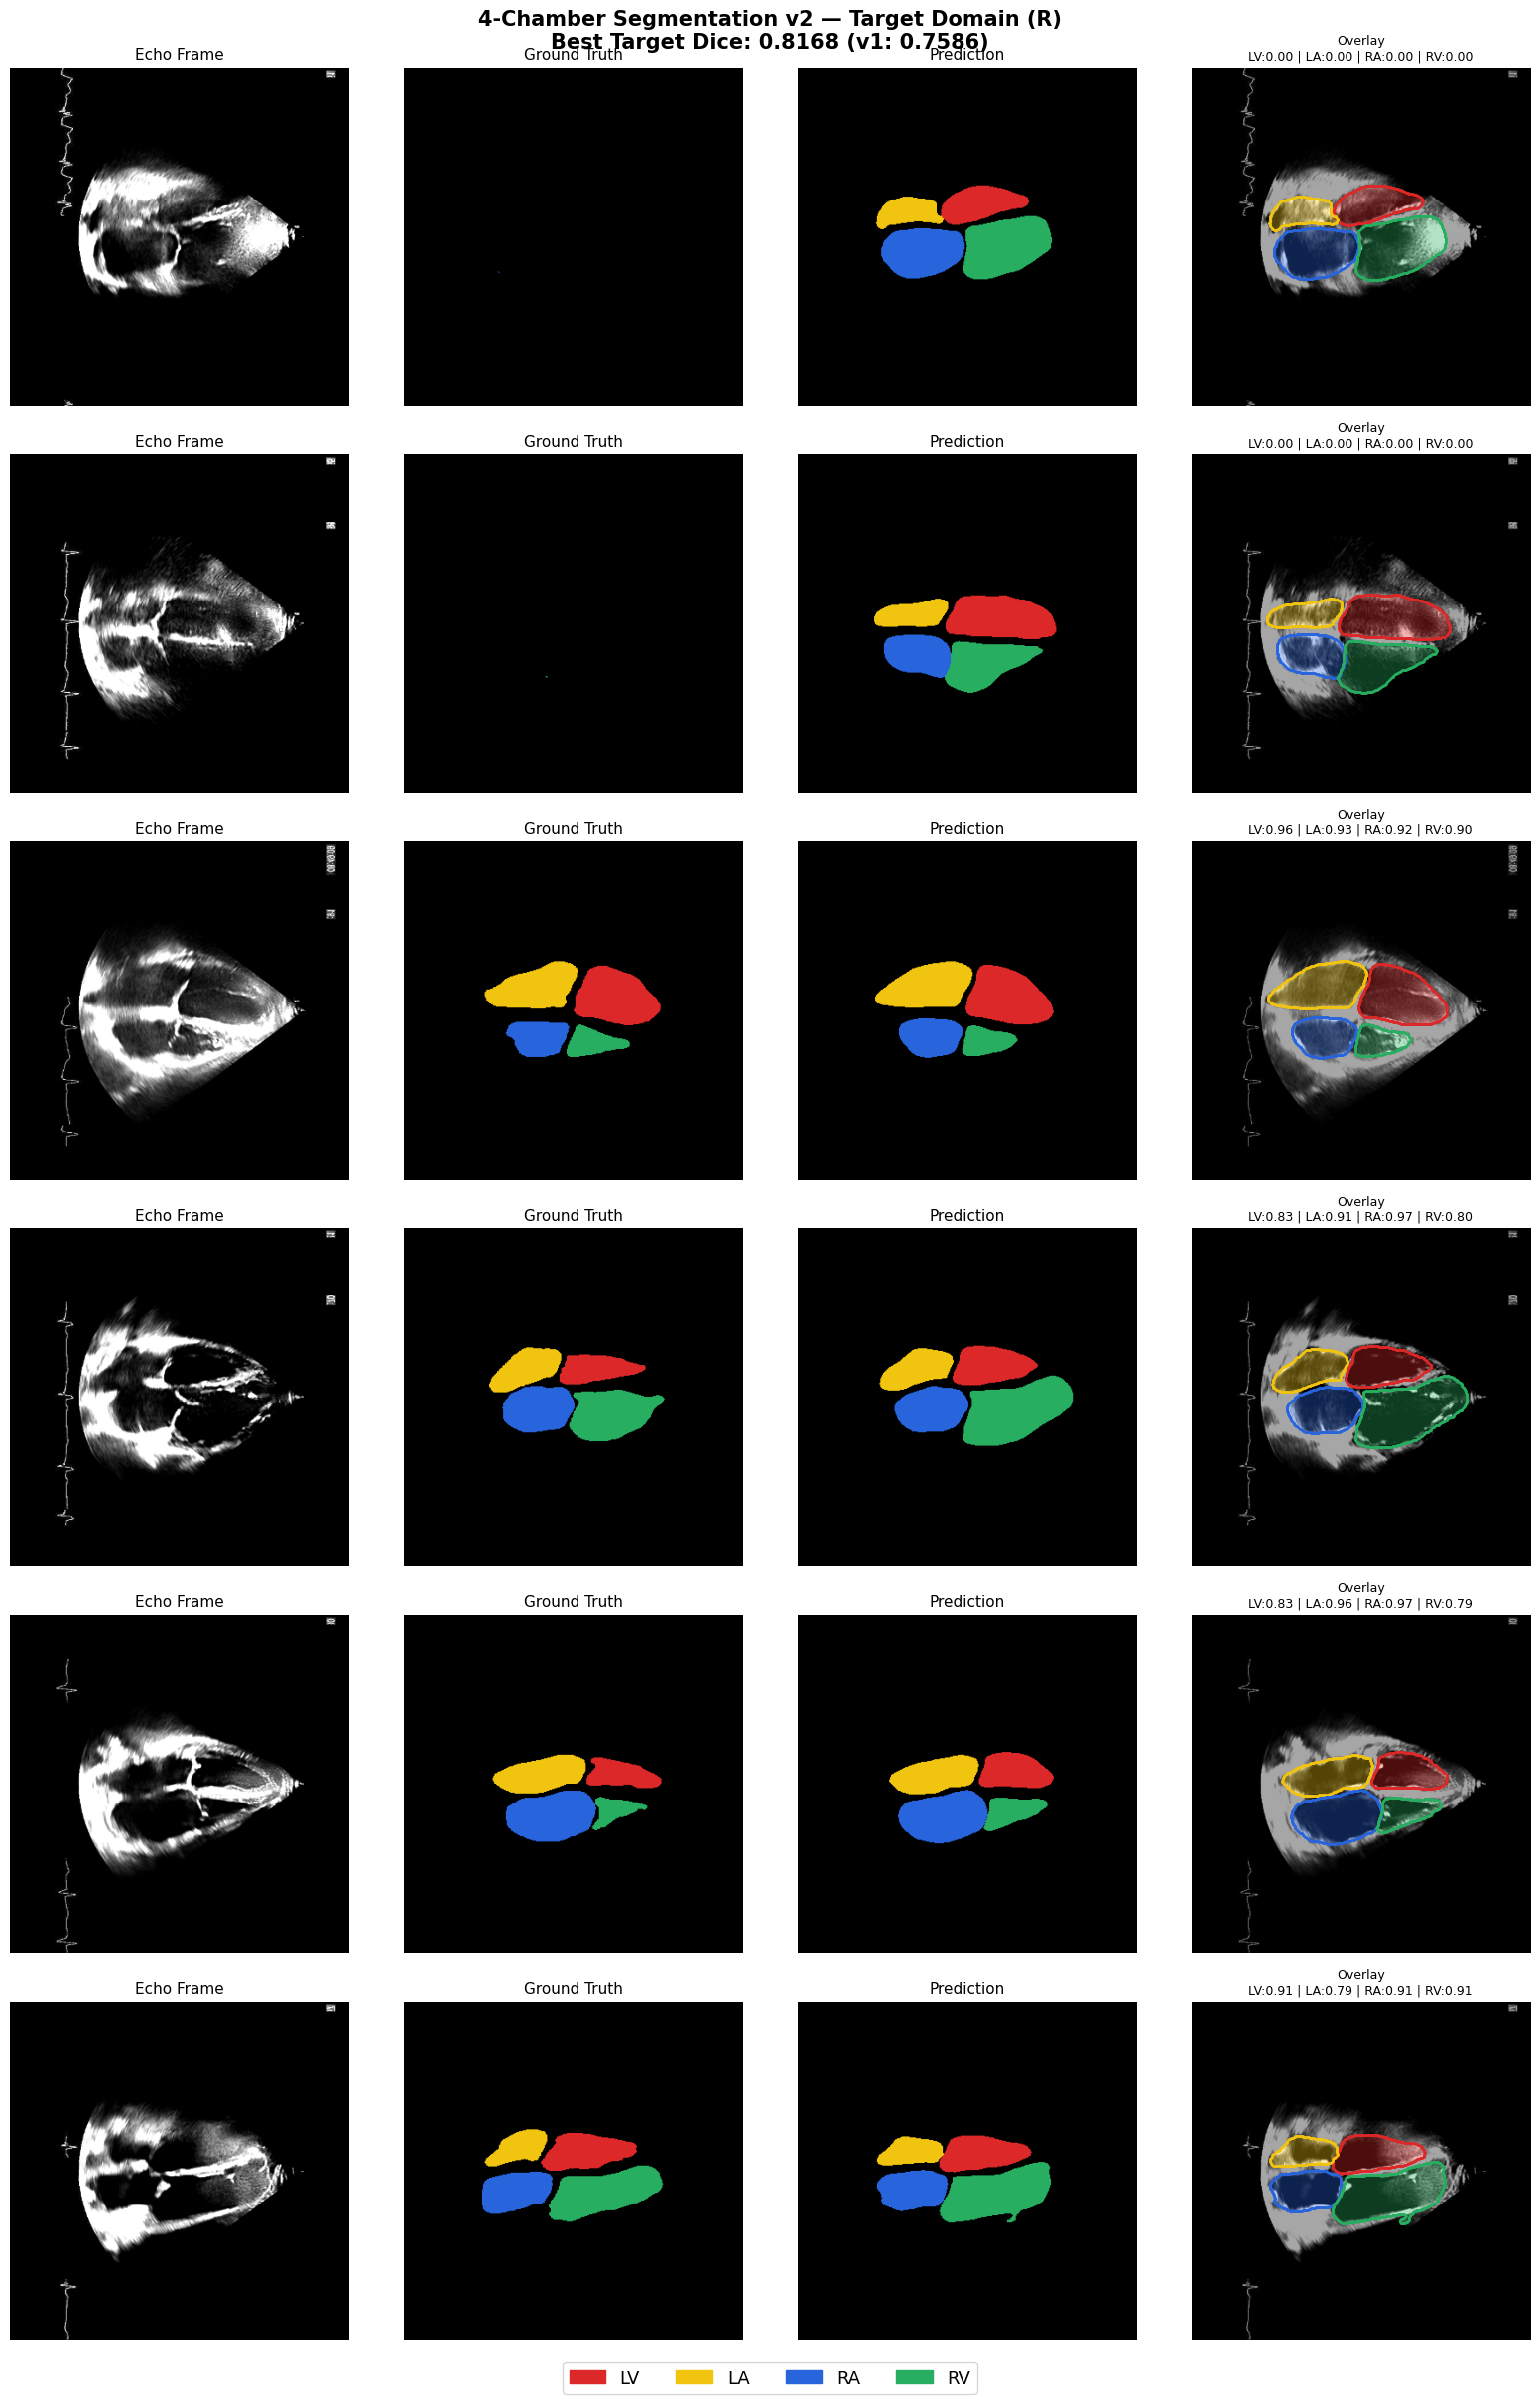

Saved to: /scratch/users/joshua04/Echo-Code/checkpoints/segmentation_results_v2.png


In [20]:
from src.inference.postprocess import largest_component, predict_with_tta
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import torch
import numpy as np
import os
from scipy import ndimage

# ── Load best v2 model ──
model.load_state_dict(torch.load(
    os.path.join(CKPT_DIR, "best_target_v2.pth"),
    map_location=device))
model.eval()


# ─────────────────────────────────────────────
# Test-time augmentation prediction
# ─────────────────────────────────────────────
def predict_with_tta(model, imgs):
    logits1 = model(imgs)

    imgs_flip = torch.flip(imgs, dims=[3])
    logits2 = model(imgs_flip)
    logits2 = torch.flip(logits2, dims=[3])

    return (logits1 + logits2) / 2.0


# ─────────────────────────────────────────────
# Color map
# ─────────────────────────────────────────────
# Unified: 0=BG, 1=LV(red), 2=RV(yellow), 3=LA(blue), 4=RA(green)
COLORS = np.array([
    [0, 0, 0],         # BG  — black
    [220, 40, 40],     # LV  — red
    [241, 196, 15],    # LA  — yellow
    [40, 100, 220],    # RA  — blue
    [39, 174, 96],     # RV  — green
], dtype=np.float32) / 255.0
LABELS = ["BG", "LV", "LA", "RA", "RV"]

# ─────────────────────────────────────────────
# Fast mask -> RGB
# ─────────────────────────────────────────────
def mask_to_rgb(mask):
    mask = mask.astype(np.int32)
    return COLORS[mask]

# ─────────────────────────────────────────────
# Draw segmentation boundaries
# ─────────────────────────────────────────────
def draw_boundaries(ax, mask):

    for c in range(1,5):

        binary = mask == c

        if binary.sum() == 0:
            continue

        edge = ndimage.binary_dilation(binary) ^ binary

        y, x = np.where(edge)
        ax.scatter(x, y, s=1, c=[COLORS[c]])


# ─────────────────────────────────────────────
# Visualization
# ─────────────────────────────────────────────
n_show = 6
fig, axes = plt.subplots(n_show, 4, figsize=(16, 4*n_show))

data_iter = iter(tgt_loader)
shown = 0


with torch.no_grad():

    for imgs, masks in data_iter:

        imgs = imgs.to(device)

        logits = predict_with_tta(model, imgs)
        preds = torch.argmax(logits, dim=1).cpu().numpy()

        imgs_np = imgs.cpu().numpy()
        masks_np = masks.cpu().numpy()

        for i in range(imgs.shape[0]):

            if shown >= n_show:
                break

            img = imgs_np[i,0]
            gt = masks_np[i]
            pred = largest_component(preds[i])

            # Safe normalization
            img_disp = (img - img.min()) / (img.max() - img.min() + 1e-6)

            gt_rgb = mask_to_rgb(gt)
            pred_rgb = mask_to_rgb(pred)

            # ── Dice per class ──
            dice_per_class = []

            for c in range(1,5):

                inter = ((pred == c) & (gt == c)).sum()
                union = (pred == c).sum() + (gt == c).sum()

                if union > 0:
                    dice = 2*inter / union
                    dice_per_class.append(f"{LABELS[c]}:{dice:.2f}")
                else:
                    dice_per_class.append(f"{LABELS[c]}:n/a")

            dice_str = " | ".join(dice_per_class)


            # ─────────────────────────
            # Column 1: Echo
            # ─────────────────────────
            axes[shown,0].imshow(img_disp, cmap="gray")
            axes[shown,0].set_title("Echo Frame", fontsize=11)


            # ─────────────────────────
            # Column 2: Ground truth
            # ─────────────────────────
            axes[shown,1].imshow(gt_rgb)
            axes[shown,1].set_title("Ground Truth", fontsize=11)


            # ─────────────────────────
            # Column 3: Prediction
            # ─────────────────────────
            axes[shown,2].imshow(pred_rgb)
            axes[shown,2].set_title("Prediction", fontsize=11)


            # ─────────────────────────
            # Column 4: Overlay
            # ─────────────────────────
            ax = axes[shown,3]

            ax.imshow(img_disp, cmap="gray")

            overlay = pred_rgb.copy()
            overlay[pred == 0] = 0

            ax.imshow(overlay, alpha=0.35)

            draw_boundaries(ax, pred)

            ax.set_title(f"Overlay\n{dice_str}", fontsize=9)


            shown += 1


        if shown >= n_show:
            break


# ─────────────────────────────────────────────
# Clean axes
# ─────────────────────────────────────────────
for ax in axes.flat:
    ax.axis("off")


# ─────────────────────────────────────────────
# Legend
# ─────────────────────────────────────────────
patches = [
    mpatches.Patch(color=COLORS[i], label=LABELS[i])
    for i in range(1,5)]

fig.legend(
    handles=patches,
    loc="lower center",
    ncol=4,
    fontsize=13,
    bbox_to_anchor=(0.5,-0.02))


# ─────────────────────────────────────────────
# Title
# ─────────────────────────────────────────────
fig.suptitle(
    "4-Chamber Segmentation v2 — Target Domain (R)\n"
    "Best Target Dice: 0.8168 (v1: 0.7586)",
    fontsize=15,
    fontweight="bold")


plt.tight_layout()

save_path = os.path.join(CKPT_DIR, "segmentation_results_v2.png")

plt.savefig(save_path, dpi=200, bbox_inches="tight")

plt.show()

print("Saved to:", save_path)